In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import MinMaxScaler

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense,Dropout
from keras.optimizers import Adam

In [2]:
df = pd.read_csv('c:\\Users\\DELL\\OneDrive\\Desktop\\Documents\\dataaaa\\AAPL_featuress.csv',parse_dates=['date'])

In [8]:
#Loaded last year's stock data for Apple Inc. (AAPL) from Yahoo Finance, including features like Open, High, Low, Close, Volume.
from datetime import datetime, timedelta
end_date = datetime.now()
start_date = end_date - timedelta(days=365) # Simple one-year calculation

# Filter the DataFrame using boolean conditions
# The '&' operator combines conditions (use parentheses for clarity)
df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

In [11]:
df.to_csv('c:\\Users\\DELL\\OneDrive\\Desktop\\Documents\\dataaaa\\AAPL_featuress.csv', index=False)
print('data saved successfully')

data saved successfully


In [6]:
df.head()

,date,open,high,low,close,volume
2276,2025-03-10 13:30:00,235.539993,236.160004,224.220001,227.479996,72071200
2277,2025-03-11 13:30:00,223.809998,225.839996,217.449997,220.839996,76137400
2278,2025-03-12 13:30:00,220.139999,221.750000,214.910004,216.979996,62547500
2279,2025-03-13 13:30:00,215.949997,216.839996,208.419998,209.679993,61368300
2280,2025-03-14 13:30:00,211.250000,213.949997,209.580002,213.490005,60107600


In [7]:
df_final = df[['close']]
split_idx = (0.8*(int(len(df))))
train_data = df_final[:int(split_idx)]
test_data = df_final[int(split_idx):]

In [8]:
test_data

,close
2467,278.779999
2468,278.029999
2469,278.279999
2470,274.109985
2471,274.609985
2472,271.839996
2473,272.190002
2474,273.670013
2475,270.970001
2476,272.359985


In [9]:
train_data.shape,test_data.shape

((191, 1), (48, 1))

In [56]:
df_final

,close
0,0.128348
1,0.121652
2,0.112723
3,0.115513
4,0.118862
...,...
11383,261.730011
11384,255.779999
11385,263.880005
11386,264.350006


In [10]:
#by splitting this way you dont take random data but split sequential data
#now for preparing data to be input for LSTM, we have to scale the data
scaler = MinMaxScaler()
train_scaled_data = scaler.fit_transform(train_data)
test_scaled_data = scaler.transform(test_data)

In [11]:
train_scaled_data

array([[0.48395882],
       [0.42559547],
       [0.39166736],
       [0.3275028 ],
       [0.36099152],
       [0.3654742 ],
       [0.35395977],
       [0.37637344],
       [0.36635322],
       [0.4030061 ],
       [0.4246286 ],
       [0.45117342],
       [0.43166036],
       [0.45205244],
       [0.39975384],
       [0.43693421],
       [0.44625123],
       [0.45240397],
       [0.27045797],
       [0.14028308],
       [0.07945863],
       [0.        ],
       [0.23231086],
       [0.15821393],
       [0.22615799],
       [0.26456891],
       [0.2612288 ],
       [0.19205419],
       [0.2158741 ],
       [0.18229766],
       [0.24013366],
       [0.28285143],
       [0.31598836],
       [0.32398698],
       [0.3315461 ],
       [0.3409511 ],
       [0.35228971],
       [0.3594973 ],
       [0.28944367],
       [0.23266239],
       [0.22932228],
       [0.20945769],
       [0.22035692],
       [0.22949811],
       [0.33725933],
       [0.3560692 ],
       [0.35079548],
       [0.343

In [12]:
def create_sequences(data,n_steps):
    X, y = [],[]
    for i in range(len(data)-n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X),np.array(y)

In [13]:
n_steps = 30
X_train,y_train = create_sequences(train_scaled_data,n_steps)
X_test,y_test = create_sequences(test_scaled_data,n_steps)

In [14]:
tf.keras.backend.set_floatx('float32')  # CPU = float32 like GPU
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)

In [15]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((161, 30, 1), (18, 30, 1), (161, 1), (18, 1))

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense,Dropout
from keras.optimizers import Adam

In [16]:
model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(30, 1)),  # Tomorrow only!
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1)  # Single price!
])

# Volatility-aware optimizer
opt= Adam(learning_rate=0.01,beta_1=0.9,beta_2=0.999,amsgrad=False,epsilon=0.00000008)
model.compile(optimizer=opt, loss='mse')
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100, verbose=1,callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', 
            patience=15, 
            restore_best_weights=True  # ← LOCKS best model!
        )])

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.1889 - val_loss: 0.2709
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0659 - val_loss: 0.0074
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0327 - val_loss: 0.0376
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0166 - val_loss: 0.0045
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0149 - val_loss: 0.0178
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0097 - val_loss: 0.0084
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0096 - val_loss: 0.0106
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0136 - val_loss: 0.0066
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0097 - val_loss: 0.0088
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0109 - val_loss: 0.0060
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0052 - val_loss: 0.0043
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0062 - val_l

In [17]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,029 (222.77 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,020 (148.52 KB)

In [18]:
n_steps = 30 
n_future = 30
current_input = df['close'].tail(n_steps).values 
current_input = scaler.transform(current_input.reshape(-1,1)) 
predictions = [] 
for i in range(n_future): 
    X = current_input.reshape(1, n_steps, 1) 
    yhat = model.predict(X, verbose=0) 
    predictions.append(yhat[0,0]) 
    current_input = np.append(current_input[1:], yhat) 
predictions_real = scaler.inverse_transform( np.array(predictions).reshape(-1,1) )

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [133]:
print(predictions_real)

[[265.1301 ]
 [265.91937]
 [266.6736 ]
 [267.39624]
 [268.07336]
 [268.69833]
 [269.27042]
 [269.79266]
 [270.26962]
 [270.7062 ]
 [271.10672]
 [271.47488]
 [271.81384]
 [272.1262 ]
 [272.41415]
 [272.67978]
 [272.9248 ]
 [273.15085]
 [273.3594 ]
 [273.55185]
 [273.72937]
 [273.89316]
 [274.04425]
 [274.1836 ]
 [274.31213]
 [274.4306 ]
 [274.53992]
 [274.6407 ]
 [274.73355]
 [274.81918]]


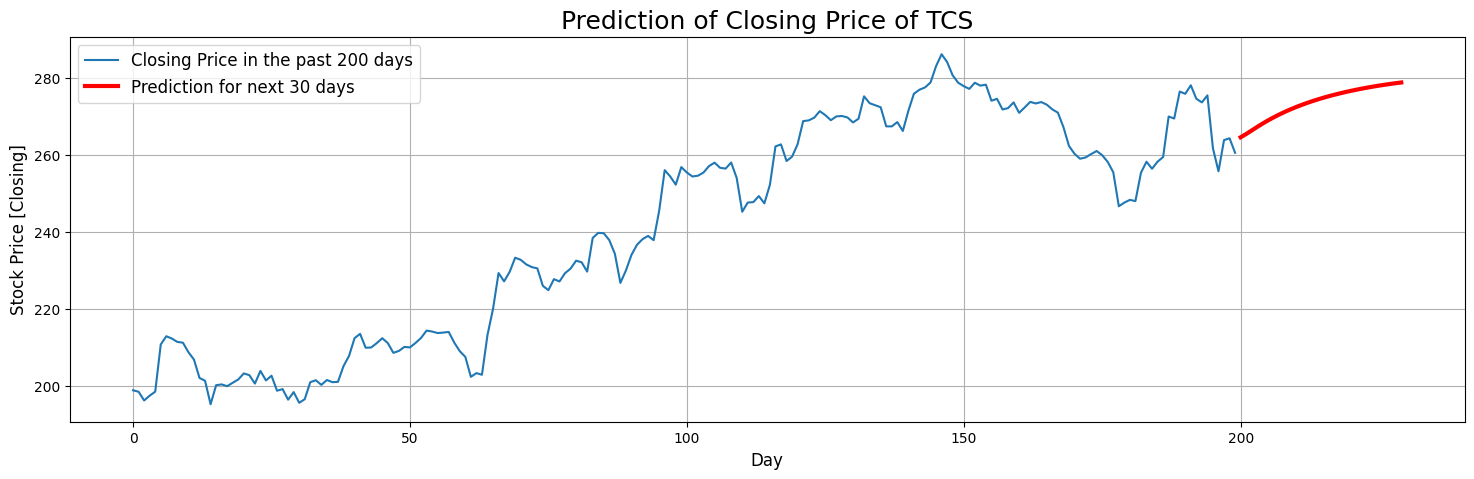

In [19]:
days=np.arange(0,200)
day_pred=np.arange(200,230)
plt.figure(figsize=(18,5))
plt.plot(days,df.close.tail(200), label = 'Closing Price in the past 200 days')
plt.plot(day_pred,predictions_real, color = 'red', label = 'Prediction for next 30 days', lw = 3)
plt.legend(fontsize = 12)
plt.title('Prediction of Closing Price of TCS', fontsize = 18)
plt.xlabel('Day' ,fontsize = 12)
plt.ylabel('Stock Price [Closing]' ,fontsize = 12)
plt.grid()
plt.show()

In [20]:
y_pred = model.predict(X_test)

# Inverse transform (only Close column matters for eval)

y_test_full = y_test
y_pred_full = y_pred.flatten()
y_test_full = y_test_full.reshape(-1, 1)
y_pred_full = y_pred_full.reshape(-1, 1)

y_test_inv = scaler.inverse_transform(y_test_full)
y_pred_inv = scaler.inverse_transform(y_pred_full)

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
RMSE: 6.19, MAE: 4.39


In [21]:
y_pred_inv[0:5], y_test_inv[0:5]

(array([[252.52557],
        [254.87814],
        [257.5922 ],
        [258.68552],
        [259.89523]], dtype=float32),
 array([[255.41000366],
        [258.26998901],
        [256.44000244],
        [258.27999878],
        [259.48001099]]))